In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data,
     housing.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
#Understand Dataset

#Shape
df.shape

#Columns
df.columns

#Information
df.info()

#Statistical Summary
df.describe()

#Missing Values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [5]:
#Separate X and Y

#Features (Input)
X = df.drop("HousePrice", axis=1)

#Target (Output)
y = df["HousePrice"]

In [6]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [8]:
#Create Models
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [9]:
#Train Models and Compare
results = []

for name, model in models.items():

    # Decision Tree does not need scaling
    if name == "Decision Tree":

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

    else:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    results.append(
        [name, rmse, r2]
    )

In [10]:
#Create Comparison Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.724234,0.599732


In [14]:
#Find Best Model
best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

best_model


,Model,RMSE,R2 Score
2,Decision Tree,0.724234,0.599732
1,Ridge Regression,0.745557,0.575816
0,Linear Regression,0.745581,0.575788


In [15]:
best_model.iloc[0]

Model       Decision Tree
RMSE             0.724234
R2 Score         0.599732
Name: 2, dtype: object

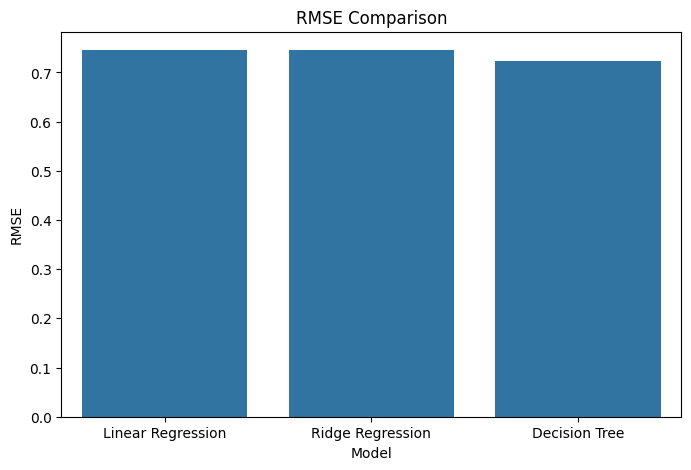

In [16]:
#Visualize Model Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="RMSE",
    data=results_df
)

plt.title("RMSE Comparison")
plt.show()

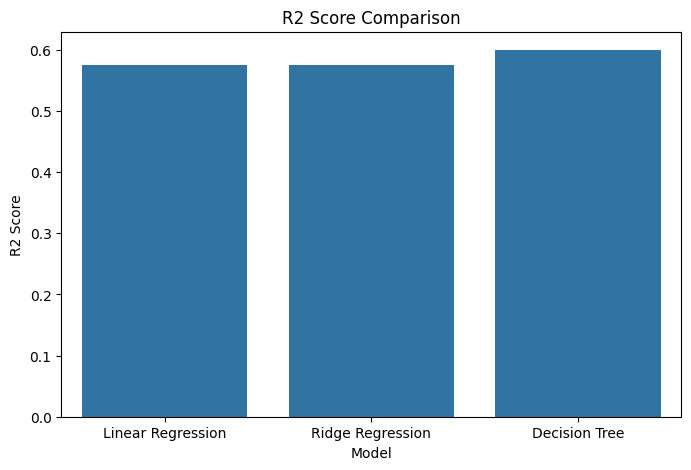

In [17]:
#R² Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)

plt.title("R2 Score Comparison")
plt.show()

In [18]:
#Actual vs Predicted Plot
best_model_name = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

print(best_model_name)

Decision Tree


In [21]:
model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

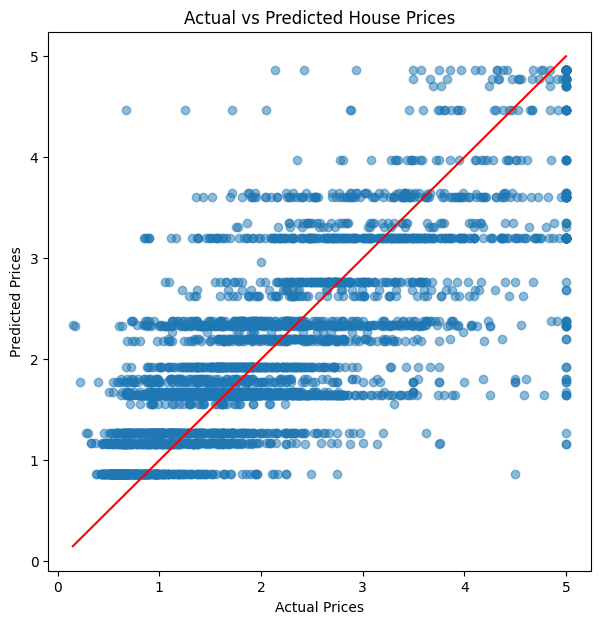

In [22]:
#Scatter Plot
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.show()

In [24]:
#Save Best Model
import joblib

joblib.dump(
    model,
    "best_house_price_model.pkl"
)

loaded_model = joblib.load(
    "best_house_price_model.pkl"
)